# Part 1b: Dropout Regularization — A/B Test
**Author:** Kalhar Mayurbhai Patel (019140511)

Demonstrates standard Dropout in TensorFlow and PyTorch with A/B comparison.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=2000, n_features=20, n_informative=10,
                           n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## TensorFlow: Dropout A/B Test

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TF Dropout=0.0: Test Acc = 0.9467
TF Dropout=0.2: Test Acc = 0.9467
TF Dropout=0.5: Test Acc = 0.9467
TF Dropout=0.7: Test Acc = 0.9417


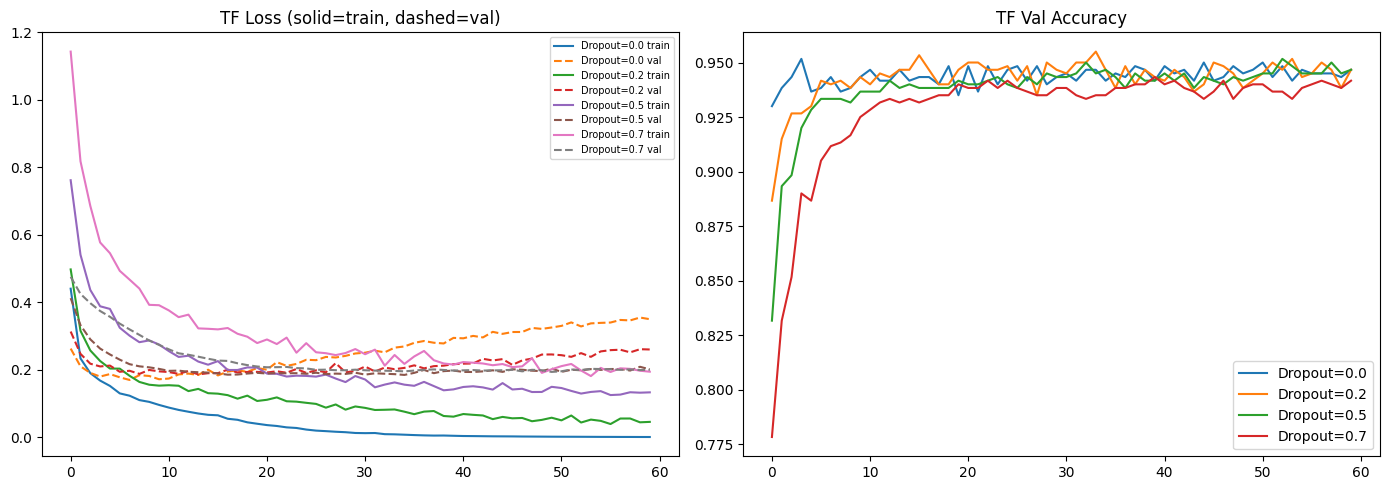

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

def build_model_tf(dropout_rate=0.0):
    return Sequential([
        layers.Dense(128, activation='relu', input_shape=(20,)),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])

results_tf = {}
for dr in [0.0, 0.2, 0.5, 0.7]:
    label = f"Dropout={dr}"
    m = build_model_tf(dr)
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train, y_train, epochs=60, batch_size=32,
              validation_data=(X_test, y_test), verbose=0)
    results_tf[label] = h.history
    _, acc = m.evaluate(X_test, y_test, verbose=0)
    print(f"TF {label}: Test Acc = {acc:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for k, v in results_tf.items():
    ax[0].plot(v['loss'], label=k+' train')
    ax[0].plot(v['val_loss'], '--', label=k+' val')
    ax[1].plot(v['val_accuracy'], label=k)
ax[0].set_title('TF Loss (solid=train, dashed=val)'); ax[0].legend(fontsize=7)
ax[1].set_title('TF Val Accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()

## PyTorch: Dropout A/B Test

PT Dropout=0.0: Final Val Acc=0.9367
PT Dropout=0.2: Final Val Acc=0.9383
PT Dropout=0.5: Final Val Acc=0.9450
PT Dropout=0.7: Final Val Acc=0.9367


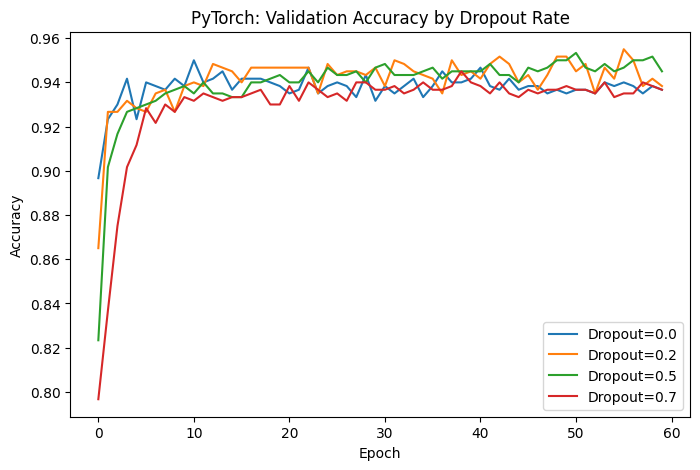

In [3]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_tr = torch.FloatTensor(X_train).to(device)
y_tr = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_te = torch.FloatTensor(X_test).to(device)
y_te = torch.FloatTensor(y_test).unsqueeze(1).to(device)
dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

class DropoutNet(nn.Module):
    def __init__(self, drop_rate=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 128), nn.ReLU(), nn.Dropout(drop_rate),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(drop_rate),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

results_pt = {}
for dr in [0.0, 0.2, 0.5, 0.7]:
    torch.manual_seed(42)
    model = DropoutNet(dr).to(device)
    opt = torch.optim.Adam(model.parameters())
    crit = nn.BCELoss()
    val_accs = []
    for ep in range(60):
        model.train()
        for xb, yb in dl:
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            va = ((model(X_te) > 0.5).float() == y_te).float().mean().item()
        val_accs.append(va)
    results_pt[f"Dropout={dr}"] = val_accs
    print(f"PT Dropout={dr}: Final Val Acc={val_accs[-1]:.4f}")

plt.figure(figsize=(8, 5))
for k, v in results_pt.items(): plt.plot(v, label=k)
plt.title('PyTorch: Validation Accuracy by Dropout Rate')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

## Observations
- **Dropout=0** (no dropout): overfits fastest — training loss drops but val loss diverges
- **Dropout=0.2–0.5**: sweet spot for most tasks; reduces overfitting while preserving capacity
- **Dropout=0.7**: too aggressive — underfitting, slow convergence
- Dropout randomly zeroes neuron outputs during training, forcing the network to learn redundant representations